## Deep Learning

### Chapter 10: Convolutional Neural Networks

Convolutional Neural Networks (CNNs) are a class of deep learning models that are particularly effective for processing data with a grid-like topology, such as images. They are designed to automatically and adaptively learn spatial hierarchies of features from input data.

Key architectural components of CNNs include:
1. **Convolutional Layers**: These layers apply a set of learnable filters (kernels) to the input data, producing feature maps that capture local patterns and spatial hierarchies.

2. **Pooling Layers**: These layers reduce the spatial dimensions of the feature maps, helping to control overfitting and improve computational efficiency. Common pooling operations include max pooling and average pooling.

In [206]:
import tensorflow as tf
from tensorflow import keras
from keras import layers
import numpy as np
import matplotlib.pyplot as plt

In [207]:
image = np.array([[1, 2, 3, 0, 1],
                  [4, 5, 6, 1, 2],
                   [7, 8, 9, 2, 3],
                    [0, 1, 2, 3, 4],
                     [1, 2, 3, 4, 5]], dtype="float32")

kernel = np.array([[1, 0, -1],
                  [1, 0, -1],
                   [1, 0, -1]], dtype="float32")

image = image.reshape((1, 5, 5, 1))
kernel = kernel.reshape((3, 3, 1, 1))

output = tf.nn.conv2d(image, kernel,
                      strides=1, padding="VALID")
print(output.numpy()[0, :, :, 0])

[[-6. 12. 12.]
 [-6.  8.  8.]
 [-6.  2.  2.]]


In [208]:
# Some helper functions
def plot_history(history, title="Training history"):
    metrics = history.history
    plt.figure(figsize=(11, 4))

    plt.subplot(1, 2, 1)
    plt.plot(metrics["accuracy"], "o-", label="Train")
    plt.plot(metrics["val_accuracy"], "o-", label="Validation")
    plt.title(title + " - Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(metrics["loss"], "o-", label="Train")
    plt.plot(metrics["val_loss"], "o-", label="Validation")
    plt.title(title + " - Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()

    plt.tight_layout()
    plt.show()


def show_images(images, labels=None, class_names=None, n=10, cmap=None):
    plt.figure(figsize=(10, 3))
    for i in range(n):
        plt.subplot(2, 5, i + 1)
        if images.shape[-1] == 1:
            plt.imshow(images[i, :, :, 0], cmap=cmap or "gray")
        else:
            plt.imshow(np.clip(images[i], 0, 1), cmap=cmap)
        if labels is not None:
            label = int(labels[i])
            title = class_names[label] if class_names else str(label)
            plt.title(title)
        plt.axis("off")
    plt.tight_layout()
    plt.show()

### Hand-Writing Digits with Convolutional Neural Networks

In [209]:
(train_images, train_labels), (test_images, test_labels) = (keras.datasets.mnist.load_data())

In [210]:
# Normalized
train_images = train_images.astype("float32") / 255.0
test_images = test_images.astype("float32") / 255.0

In [211]:
# Add a channel dimension

train_images = np.expand_dims(train_images, axis=-1)
test_images = np.expand_dims(test_images, axis=-1)

# Return shape
print(train_images.shape)
print(test_images.shape)

(60000, 28, 28, 1)
(10000, 28, 28, 1)


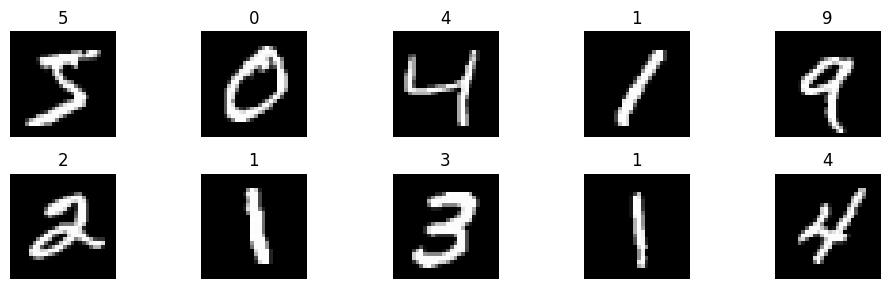

In [212]:
show_images(train_images, train_labels, n=10, cmap="gray")

In [213]:
image = train_images[0, :, :, 0]

patches = []

for row in range(24):
    for col in range(24):
        patch = image[row:row+5, col:col+5]
        patches.append(patch)

print("Number of 5x5 patches:", len(patches))

Number of 5x5 patches: 576


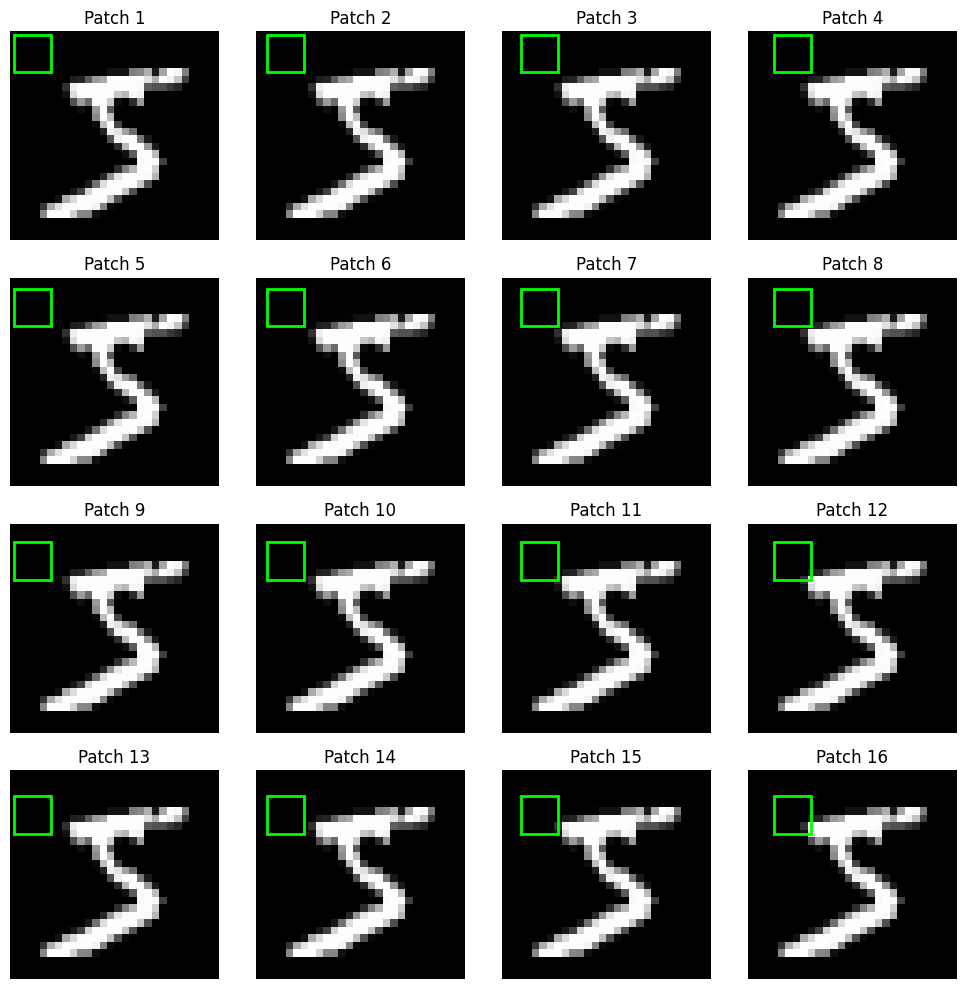

In [214]:
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

fig, axes = plt.subplots(4, 4, figsize=(10, 10))

patch_num = 1

for row in range(4):
    for col in range(4):
        ax = axes[row, col]

        ax.imshow(image, cmap='gray')

        rect = Rectangle((col, row),  # x, y
                         5,           # width
                         5,           # height
                         linewidth=2,
                         edgecolor='lime',
                         facecolor='none')

        ax.add_patch(rect)
        ax.set_title(f"Patch {patch_num}")
        ax.axis('off')

        patch_num += 1

plt.tight_layout()
plt.show()

In [215]:
kernel = np.array([
    [1, 0, -1, 0, 1],
    [1, 0, -1, 0, 1],
    [1, 0, -1, 0, 1],
    [1, 0, -1, 0, 1],
    [1, 0, -1, 0, 1]
])

feature_map = np.zeros((24, 24))

for row in range(24):
    for col in range(24):
        patch = image[row:row+5, col:col+5]
        feature_map[row, col] = np.sum(patch * kernel)

In [216]:
vertical_edge_kernel = np.array([[-1, 0, 1],
                                  [-1, 0, 1],
                                   [-1, 0, 1]],
                                dtype="float32")

horizontal_edge_kernel = np.array([[-1, -1, -1],
                                    [0,  0,  0],
                                     [1,  1,  1]],
                                  dtype="float32")

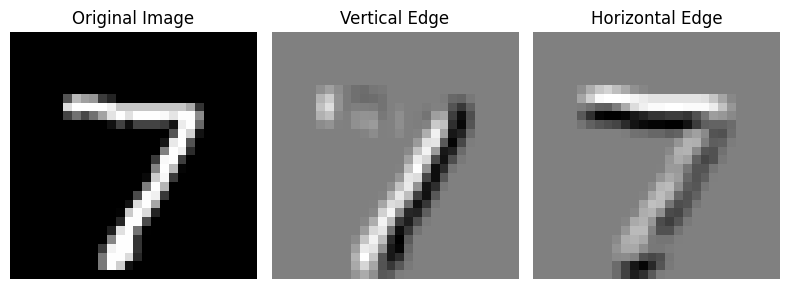

In [217]:
# Use [0:1] to preserve the batch size dimension
 # (i.e., (1, 28, 28, 1) instead of (28, 28, 1))
sample = test_images[0:1]

kernels = {"Vertical Edge": vertical_edge_kernel,
           "Horizontal Edge": horizontal_edge_kernel,}

plt.figure(figsize=(8, 3))
plt.subplot(1, 3, 1)
plt.imshow(sample[0, :, :, 0], cmap="gray")
plt.title("Original Image")
plt.axis("off")

for i, (name, kernel) in enumerate(kernels.items(), start=2):
    kernel_4d = kernel.reshape((3, 3, 1, 1))
    response = tf.nn.conv2d(sample, kernel_4d, strides=1, padding="SAME").numpy()
    plt.subplot(1, 3, i)
    plt.imshow(response[0, :, :, 0], cmap="gray")
    plt.title(name)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [218]:
kernel = np.array([
    [1, 0, -1, 0, 1],
    [1, 0, -1, 0, 1],
    [1, 0, -1, 0, 1],
    [1, 0, -1, 0, 1],
    [1, 0, -1, 0, 1]
])

In [219]:
feature_map = np.zeros((24, 24))

for row in range(24):
    for col in range(24):
        patch = image[row:row+5, col:col+5]
        feature_map[row, col] = np.sum(patch * kernel)

In [220]:
def build_mnist_convnet():
    inputs = keras.Input(shape=(28, 28, 1))

    # Convolutional feature extraction
    x = layers.Conv2D(filters=32, kernel_size=3, activation="relu", name="conv_1")(inputs)
    x = layers.MaxPooling2D(pool_size=2, name="pool_1")(x)

    x = layers.Conv2D(filters=64, kernel_size=3, activation="relu", name="conv_2")(x)
    x = layers.MaxPooling2D(pool_size=2, name="pool_2")(x)

    x = layers.Conv2D(filters=128, kernel_size=3, activation="relu", name="conv_3")(x)

    # Classification head
    x = layers.Flatten()(x)
    outputs = layers.Dense(10, activation='softmax')(x)

    model = keras.Model(inputs=inputs, outputs=outputs)
    return model

In [221]:
mnist_convnet = build_mnist_convnet()

mnist_convnet.compile(optimizer="rmsprop",
                      loss="sparse_categorical_crossentropy",
                      metrics=["accuracy"],)
mnist_convnet.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_1 (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool_1 (MaxPooling2D)           │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_2 (Conv2D)                 │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool_2 (MaxPooling2D)           │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_3 (Conv2D)                 │ (None, 3, 3, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 1152)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │        11,530 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 104,202 (407.04 KB)

 Trainable params: 104,202 (407.04 KB)

 Non-trainable params: 0 (0.00 B)

In [222]:
FAST_RUN = True

epochs = 2 if FAST_RUN else 5

history_mnist = mnist_convnet.fit(train_images, train_labels,
                            epochs=epochs,
                            validation_data=(test_images, test_labels))

Epoch 1/2
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 36s 19ms/step - accuracy: 0.9600 - loss: 0.1288 - val_accuracy: 0.9762 - val_loss: 0.0689
Epoch 2/2
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 37s 20ms/step - accuracy: 0.9874 - loss: 0.0411 - val_accuracy: 0.9882 - val_loss: 0.0347


MNIST test accuracy: 0.9882


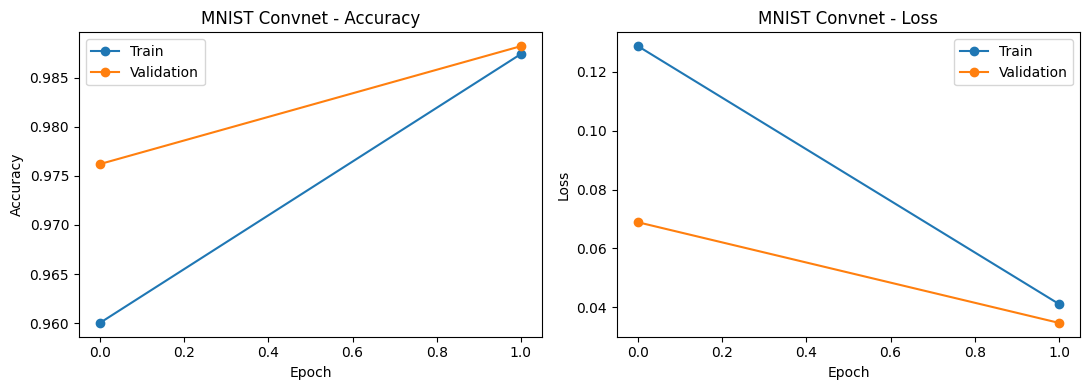

In [223]:
test_loss, test_acc = mnist_convnet.evaluate(test_images, test_labels, verbose=0)
print(f"MNIST test accuracy: {test_acc:.4f}")

plot_history(history_mnist, "MNIST Convnet")

In [224]:
def build_dense_mnist_model():
    inputs = keras.Input(shape=(28, 28, 1))

    x = layers.Flatten()(inputs)
    x = layers.Dense(256, activation="relu")(x)
    outputs = layers.Dense(10, activation="softmax")(x)

    model = keras.Model(inputs, outputs)
    return model

Epoch 1/2
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9344 - loss: 0.2238 - val_accuracy: 0.9607 - val_loss: 0.1378
Epoch 2/2
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9710 - loss: 0.0987 - val_accuracy: 0.9739 - val_loss: 0.0884
Dense test accuracy: 0.9739


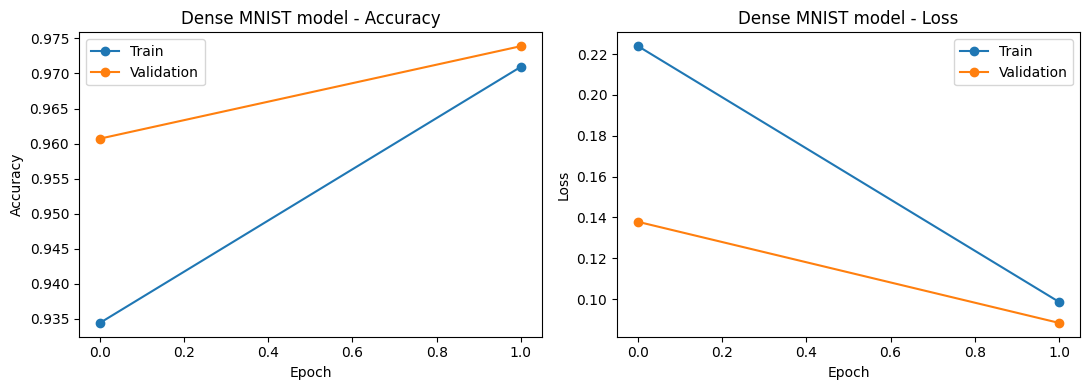

In [225]:
dense_model = build_dense_mnist_model()

dense_model.compile(optimizer="rmsprop",
                    loss="sparse_categorical_crossentropy",
                    metrics=["accuracy"],)

history_dense = dense_model.fit(train_images, train_labels,
                                epochs=epochs,
                                validation_data=(test_images, test_labels),)

dense_test_loss, dense_test_acc = dense_model.evaluate(test_images, test_labels, verbose=0)
print(f"Dense test accuracy: {dense_test_acc:.4f}")

plot_history(history_dense, "Dense MNIST model")

In [226]:
activation_model = keras.Model(inputs=mnist_convnet.input,
                               outputs=mnist_convnet.get_layer("conv_1").output,)

activations = activation_model.predict(test_images[0:1], verbose=0)
print("Activation shape:", activations.shape)

Activation shape: (1, 26, 26, 32)


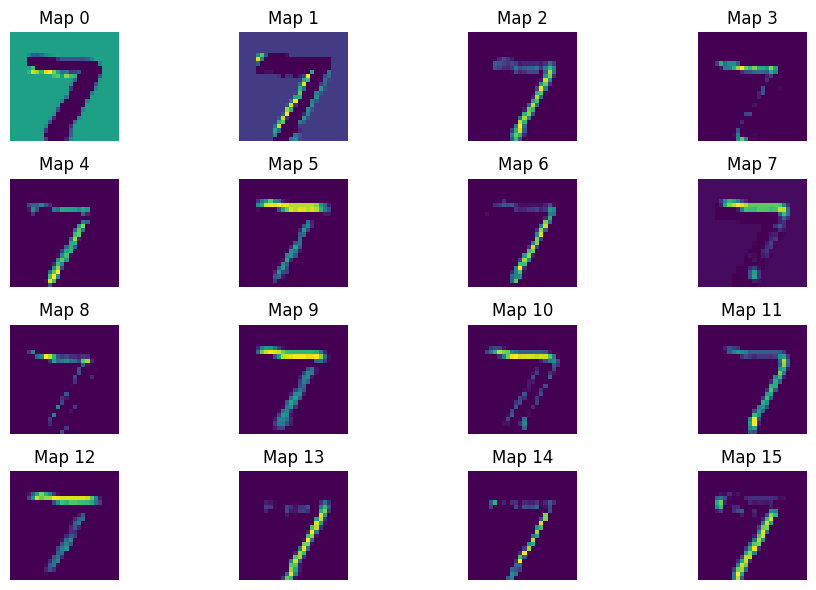

In [227]:
plt.figure(figsize=(10, 6))

for i in range(16):
    plt.subplot(4, 4, i + 1)
    plt.imshow(activations[0, :, :, i], cmap="viridis")
    plt.title(f"Map {i}")
    plt.axis("off")

plt.tight_layout()
plt.show()

### Image Classification with Convolutional Neural Networks

In [228]:
(cifar_train, cifar_y_train), (cifar_test, cifar_y_test) = keras.datasets.cifar10.load_data()

cifar_y_train = cifar_y_train.squeeze()
cifar_y_test = cifar_y_test.squeeze()

CAT_LABEL = 3
DOG_LABEL = 5

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 405s 2us/step


In [229]:
def filter_cat_dog(images, labels):
    mask = np.isin(labels, [CAT_LABEL, DOG_LABEL])
    images = images[mask].astype("float32") / 255.0
    labels = labels[mask]
    labels = (labels == DOG_LABEL).astype("float32")
    return images, labels

In [230]:
cd_images, cd_labels = filter_cat_dog(cifar_train, cifar_y_train)
cd_test_images, cd_test_labels = filter_cat_dog(cifar_test, cifar_y_test)

print("Cat/Dog train pool:", cd_images.shape, cd_labels.shape)
print("Cat/Dog test:", cd_test_images.shape, cd_test_labels.shape)

Cat/Dog train pool: (10000, 32, 32, 3) (10000,)
Cat/Dog test: (2000, 32, 32, 3) (2000,)


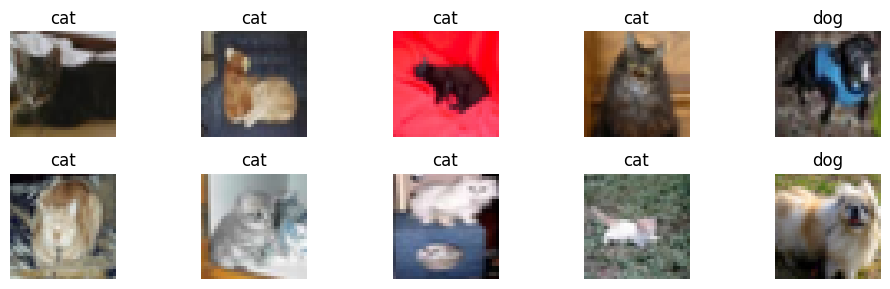

In [231]:
show_images(cd_images, cd_labels, class_names={0: "cat", 1: "dog"}, n=10)

In [232]:
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

n_per_class_train = 700 if FAST_RUN else 2000
n_per_class_val = 200 if FAST_RUN else 500

cat_indices = np.where(cd_labels == 0)[0]
dog_indices = np.where(cd_labels == 1)[0]

rng = np.random.default_rng(SEED)
rng.shuffle(cat_indices)
rng.shuffle(dog_indices)

In [233]:
train_indices = np.r_[cat_indices[:n_per_class_train],
                      dog_indices[:n_per_class_train],]

val_indices = np.r_[cat_indices[n_per_class_train:n_per_class_train
                                + n_per_class_val],
                    dog_indices[n_per_class_train:n_per_class_train
                                + n_per_class_val],]

rng.shuffle(train_indices)
rng.shuffle(val_indices)

In [234]:
x_cd_train = cd_images[train_indices]
y_cd_train = cd_labels[train_indices]

x_cd_val = cd_images[val_indices]
y_cd_val = cd_labels[val_indices]

print("x_cd_train:", x_cd_train.shape)
print("x_cd_val:", x_cd_val.shape)
print("cd_test_images:", cd_test_images.shape)

x_cd_train: (1400, 32, 32, 3)
x_cd_val: (400, 32, 32, 3)
cd_test_images: (2000, 32, 32, 3)


In [235]:
def build_catdog_baseline():
    inputs = keras.Input(shape=(32, 32, 3))

    x = layers.Conv2D(32, 3, activation="relu")(inputs)
    x = layers.MaxPooling2D(2)(x)

    x = layers.Conv2D(64, 3, activation="relu")(x)
    x = layers.MaxPooling2D(2)(x)

    x = layers.Conv2D(128, 3, activation="relu")(x)

    x = layers.Flatten()(x)
    outputs = layers.Dense(1, activation="sigmoid")(x)

    model = keras.Model(inputs, outputs)
    model.compile(optimizer="rmsprop",
                  loss="binary_crossentropy",
                  metrics=["accuracy"],)

    return model

In [236]:
catdog_baseline = build_catdog_baseline()
catdog_baseline.summary()

Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 4, 4, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │         2,049 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 95,297 (372.25 KB)

 Trainable params: 95,297 (372.25 KB)

 Non-trainable params: 0 (0.00 B)

In [237]:
epochs_cd = 4 if FAST_RUN else 20

history_cd = catdog_baseline.fit(x_cd_train, y_cd_train,
                                 epochs=epochs_cd, batch_size=64,
                                 validation_data=(x_cd_val, y_cd_val),)

Epoch 1/4
22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 58ms/step - accuracy: 0.5086 - loss: 0.6974 - val_accuracy: 0.5175 - val_loss: 0.6861
Epoch 2/4
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 66ms/step - accuracy: 0.5386 - loss: 0.6856 - val_accuracy: 0.5525 - val_loss: 0.6772
Epoch 3/4
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 54ms/step - accuracy: 0.5771 - loss: 0.6745 - val_accuracy: 0.5900 - val_loss: 0.6722
Epoch 4/4
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 54ms/step - accuracy: 0.6071 - loss: 0.6610 - val_accuracy: 0.6150 - val_loss: 0.6684


Baseline Cat/Dog test accuracy: 0.5890


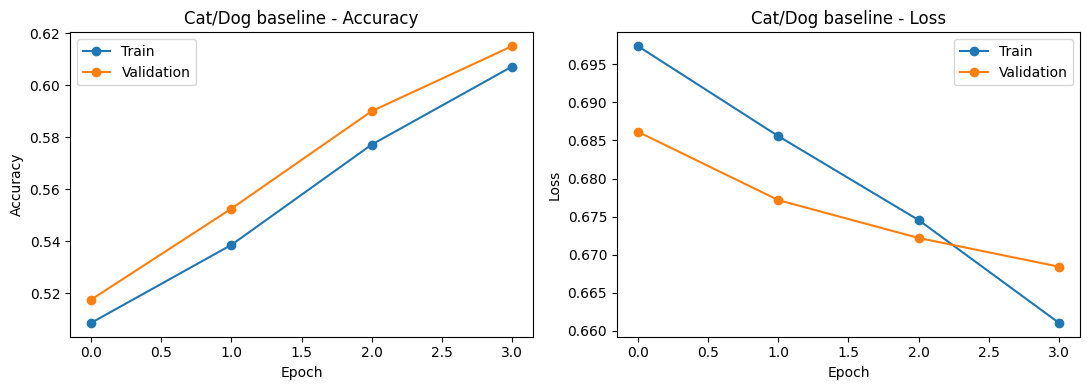

In [238]:
test_loss, test_acc = catdog_baseline.evaluate(cd_test_images, cd_test_labels, verbose=0)
print(f"Baseline Cat/Dog test accuracy: {test_acc:.4f}")

plot_history(history_cd, "Cat/Dog baseline")

In [239]:
data_augmentation = keras.Sequential([layers.RandomFlip("horizontal"),
                                      layers.RandomRotation(0.08),
                                      layers.RandomZoom(0.15),],
                                     name="data_augmentation",)

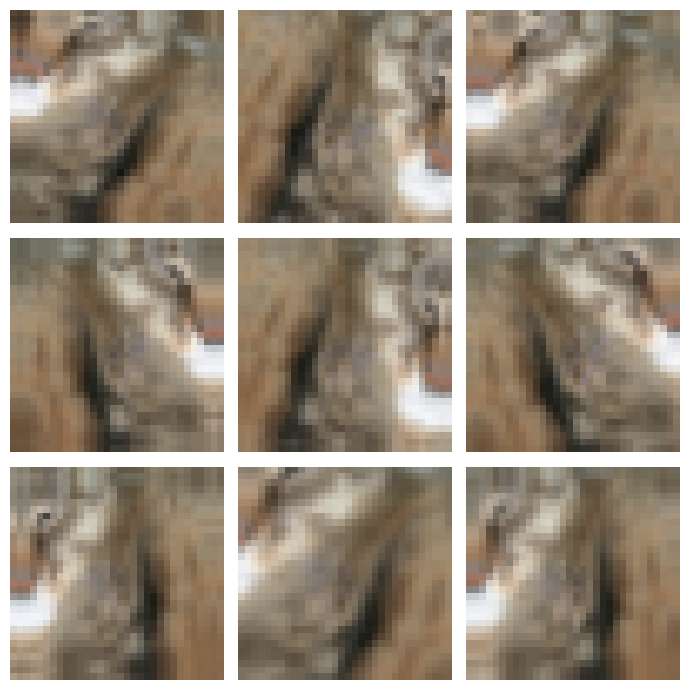

In [240]:
sample_img = x_cd_train[0:1]

plt.figure(figsize=(7, 7))

for i in range(9):
    augmented = data_augmentation(sample_img, training=True)

    plt.subplot(3, 3, i + 1)
    plt.imshow(np.clip(augmented[0].numpy(), 0, 1))
    plt.axis("off")

plt.tight_layout()
plt.show()

In [241]:
def build_catdog_augmented():
    inputs = keras.Input(shape=(32, 32, 3))

    x = data_augmentation(inputs)

    x = layers.Conv2D(32, 3, activation="relu")(x)
    x = layers.MaxPooling2D(2)(x)

    x = layers.Conv2D(64, 3, activation="relu")(x)
    x = layers.MaxPooling2D(2)(x)

    x = layers.Conv2D(128, 3, activation="relu")(x)

    x = layers.Flatten()(x)

    x = layers.Dropout(0.5)(x)

    outputs = layers.Dense(1, activation="sigmoid")(x)

    model = keras.Model(inputs, outputs)

    model.compile(optimizer="rmsprop", loss="binary_crossentropy",
                  metrics=["accuracy"],)

    return model

In [242]:
catdog_augmented = build_catdog_augmented()
catdog_augmented.summary()

history_aug = catdog_augmented.fit(x_cd_train,
                                   y_cd_train,
                                   epochs=4 if FAST_RUN else 30,
                                   batch_size=64,
                                   validation_data=(x_cd_val, y_cd_val),)

Model: "functional_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_6 (InputLayer)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 4, 4, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │         2,049 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 95,297 (372.25 KB)

 Trainable params: 95,297 (372.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/4
22/22 ━━━━━━━━━━━━━━━━━━━━ 3s 67ms/step - accuracy: 0.5314 - loss: 0.6957 - val_accuracy: 0.5175 - val_loss: 0.6896
Epoch 2/4
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 60ms/step - accuracy: 0.5221 - loss: 0.6907 - val_accuracy: 0.5200 - val_loss: 0.6856
Epoch 3/4
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 61ms/step - accuracy: 0.5429 - loss: 0.6888 - val_accuracy: 0.5400 - val_loss: 0.6809
Epoch 4/4
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 60ms/step - accuracy: 0.5543 - loss: 0.6849 - val_accuracy: 0.5450 - val_loss: 0.6768


Augmented Cat/Dog test accuracy: 0.5570


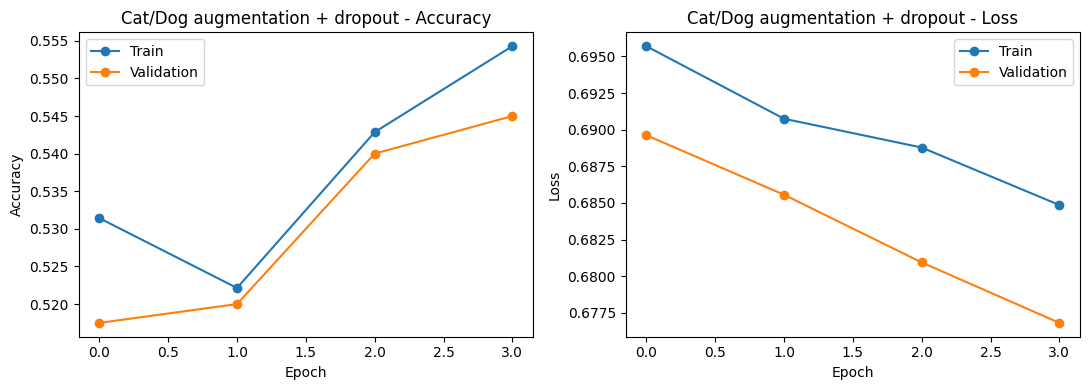

In [243]:
test_loss, test_acc = catdog_augmented.evaluate(cd_test_images, cd_test_labels, verbose=0)
print(f"Augmented Cat/Dog test accuracy: {test_acc:.4f}")

plot_history(history_aug, "Cat/Dog augmentation + dropout")